# Feature Engineering con Redes Neuronales Recurrentes (RNN)
## Extracción de características temporales para predicción de rendimiento agrícola

---

### Objetivo
Utilizar RNNs (LSTM/GRU) con **PyTorch** para generar features automáticamente a partir de:
- **Series temporales mensuales**: Variables climáticas (temperatura, precipitación)
- **Variables anuales replicadas**: Datos de suelo, producción, etc.

### Estrategia
1. Preparar secuencias mensuales por cultivo/departamento/año
2. Entrenar un LSTM encoder para aprender representaciones latentes
3. Extraer embeddings temporales como nuevas features
4. Usar estas features en modelos predictivos downstream

---

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Usando CPU")

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsando device: {device}")

PyTorch version: 2.9.1
CUDA disponible: False
Usando CPU

Usando device: cpu


## 1. Carga y Exploración de Datos

In [7]:
print("="*80)
print("CARGA DE DATOS")
print("="*80)

# Cargar dataset
df = pd.read_csv('dataset_final_clima_completo.csv')
print(f"\n✓ Dataset cargado: {len(df):,} registros")
print(f"✓ Columnas: {list(df.columns)}")
print(f"✓ Rango temporal: {df['año'].min()} - {df['año'].max()}")
print(f"✓ Cultivos únicos: {df['cultivo'].nunique()}")
print(f"✓ Departamentos únicos: {df['departamento_nombre'].nunique()}")

# Mostrar primeras filas
print("\n" + "="*80)
print("PRIMERAS FILAS")
print("="*80)
df.head()

CARGA DE DATOS

✓ Dataset cargado: 1,441,934 registros
✓ Columnas: ['provincia_nombre', 'departamento_nombre', 'departamento_id', 'cultivo', 'año', 'mes', 'rendimiento', 'temperatura_celsius', 'precipitacion_mm', 'suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 'suelo_alcalin_s1', 'produccion', 'sup_sembrada']
✓ Rango temporal: 1970 - 2025
✓ Cultivos únicos: 34
✓ Departamentos únicos: 405

PRIMERAS FILAS


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion,sup_sembrada
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,1,3333,22.368317,5.617142,34.550898,66.545659,77.879491,No sodico,10,3
1,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,2,3333,23.294342,1.991272,34.550898,66.545659,77.879491,No sodico,10,3
2,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,3,3333,19.947906,6.193161,34.550898,66.545659,77.879491,No sodico,10,3
3,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,4,3333,18.099762,3.725052,34.550898,66.545659,77.879491,No sodico,10,3
4,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,5,3333,12.083649,0.638962,34.550898,66.545659,77.879491,No sodico,10,3


In [8]:
# Verificar estructura temporal
print("="*80)
print("ESTRUCTURA TEMPORAL")
print("="*80)

# Ejemplo: Un año de un cultivo en un departamento
sample = df[(df['cultivo'] == 'Soja') & 
            (df['año'] == 2020) & 
            (df['departamento_nombre'] == df['departamento_nombre'].iloc[0])].sort_values('mes')

if len(sample) > 0:
    print(f"\nEjemplo: Soja en {sample['departamento_nombre'].iloc[0]} - Año 2020")
    print(f"Meses disponibles: {sorted(sample['mes'].unique())}")
    print(f"Total meses: {len(sample)}")
    print("\nDatos por mes:")
    print(sample[['mes', 'temperatura_celsius', 'precipitacion_mm', 'rendimiento']].head(12))
else:
    print("\n⚠️ No hay datos de Soja para 2020, mostrando otro ejemplo...")
    sample = df.groupby(['cultivo', 'departamento_nombre', 'año']).filter(lambda x: len(x) >= 12).head(12)
    print(sample[['cultivo', 'departamento_nombre', 'año', 'mes', 'temperatura_celsius', 'precipitacion_mm']])

ESTRUCTURA TEMPORAL

⚠️ No hay datos de Soja para 2020, mostrando otro ejemplo...
   cultivo departamento_nombre   año  mes  temperatura_celsius  \
0      Ajo          25 DE MAYO  1970    1            22.368317   
1      Ajo          25 DE MAYO  1970    2            23.294342   
2      Ajo          25 DE MAYO  1970    3            19.947906   
3      Ajo          25 DE MAYO  1970    4            18.099762   
4      Ajo          25 DE MAYO  1970    5            12.083649   
5      Ajo          25 DE MAYO  1970    6             8.224274   
6      Ajo          25 DE MAYO  1970    7             8.897369   
7      Ajo          25 DE MAYO  1970    8             9.852448   
8      Ajo          25 DE MAYO  1970    9            14.838287   
9      Ajo          25 DE MAYO  1970   10            14.759918   
10     Ajo          25 DE MAYO  1970   11            17.033112   
11     Ajo          25 DE MAYO  1970   12            21.553620   

    precipitacion_mm  
0           5.617142  
1           1

## 2. Preparación de Secuencias Temporales

Vamos a crear secuencias mensuales donde:
- Cada **secuencia** = 12 meses de datos climáticos para un cultivo/departamento/año
- **Features temporales**: temperatura, precipitación (variables mensuales)
- **Features estáticas**: suelo, ubicación (replicadas en cada mes)

In [9]:
print("="*80)
print("SELECCIÓN DE CULTIVO PARA MODELADO")
print("="*80)

# Configuración: Seleccionar cultivo con suficientes datos
CULTIVO_SELECCIONADO = 'Maíz'  # Cambiar según necesites

# Mostrar cultivos disponibles
print("\n📋 Top 10 cultivos por cantidad de registros:")
cultivos_top = df['cultivo'].value_counts().head(10)
for i, (cultivo, count) in enumerate(cultivos_top.items(), 1):
    pct = (count / len(df)) * 100
    print(f"   {i:2}. {cultivo:30} - {count:8,} registros ({pct:5.2f}%)")

# Filtrar por cultivo
df_cultivo = df[df['cultivo'].str.upper() == CULTIVO_SELECCIONADO.upper()].copy()

if len(df_cultivo) == 0:
    print(f"\n❌ ERROR: No hay datos para '{CULTIVO_SELECCIONADO}'")
    print("Por favor, cambia CULTIVO_SELECCIONADO a uno de la lista anterior.")
else:
    print(f"\n✓ Cultivo seleccionado: '{df_cultivo['cultivo'].iloc[0]}'")
    print(f"✓ Registros: {len(df_cultivo):,}")
    print(f"✓ Años: {df_cultivo['año'].min()} - {df_cultivo['año'].max()}")
    print(f"✓ Departamentos: {df_cultivo['departamento_nombre'].nunique()}")

SELECCIÓN DE CULTIVO PARA MODELADO

📋 Top 10 cultivos por cantidad de registros:
    1. Maíz                           -  211,574 registros (14.67%)
    2. Sorgo                          -  144,640 registros (10.03%)
    3. Avena                          -  137,508 registros ( 9.54%)
    4. Girasol                        -  127,130 registros ( 8.82%)
    5. Cebada forrajera               -   78,840 registros ( 5.47%)
    6. Soja 1ra                       -   76,590 registros ( 5.31%)
    7. Centeno                        -   72,046 registros ( 5.00%)
    8. Soja 2da                       -   60,744 registros ( 4.21%)
    9. Cebada cervecera               -   53,100 registros ( 3.68%)
   10. Algodón                        -   51,750 registros ( 3.59%)

✓ Cultivo seleccionado: 'Maíz'
✓ Registros: 211,574
✓ Años: 1970 - 2025
✓ Departamentos: 370


In [10]:
print("="*80)
print("CREACIÓN DE SECUENCIAS TEMPORALES")
print("="*80)

# Definir features
# Features temporales (varían por mes)
temporal_features = ['temperatura_celsius', 'precipitacion_mm']

# Features estáticas (constantes por año/departamento)
static_features = ['suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1']

# Target
target = 'rendimiento'

print(f"\nFeatures temporales (mensuales): {temporal_features}")
print(f"Features estáticas (anuales): {static_features}")
print(f"Target: {target}")

# Función para crear secuencias
def create_sequences(df, temporal_cols, static_cols, target_col, seq_length=12):
    """
    Crea secuencias de series temporales.
    
    Args:
        df: DataFrame con datos
        temporal_cols: Columnas que varían por mes
        static_cols: Columnas constantes por año/departamento
        target_col: Variable objetivo
        seq_length: Longitud de la secuencia (meses)
    
    Returns:
        X_temporal: Array (n_samples, seq_length, n_temporal_features)
        X_static: Array (n_samples, n_static_features)
        y: Array (n_samples,)
        metadata: DataFrame con info de cada secuencia
    """
    sequences_temporal = []
    sequences_static = []
    targets = []
    metadata_list = []
    
    # Agrupar por año y departamento
    grouped = df.groupby(['año', 'departamento_nombre'])
    
    for (año, dept), group in grouped:
        # Ordenar por mes
        group_sorted = group.sort_values('mes')
        
        # Verificar que tenemos 12 meses completos
        if len(group_sorted) != seq_length:
            continue
        
        # Verificar que no hay valores faltantes en features clave
        if group_sorted[temporal_cols + static_cols + [target_col]].isnull().any().any():
            continue
        
        # Extraer secuencia temporal (12 meses x n_features)
        seq_temporal = group_sorted[temporal_cols].values
        
        # Extraer features estáticas (tomar el primer valor, son constantes por año)
        seq_static = group_sorted[static_cols].iloc[0].values
        
        # Target (mismo para todos los meses de ese año/departamento)
        target_val = group_sorted[target_col].iloc[0]
        
        sequences_temporal.append(seq_temporal)
        sequences_static.append(seq_static)
        targets.append(target_val)
        
        # Metadata
        metadata_list.append({
            'año': año,
            'departamento_nombre': dept,
            'provincia_nombre': group_sorted['provincia_nombre'].iloc[0],
            'cultivo': group_sorted['cultivo'].iloc[0]
        })
    
    X_temporal = np.array(sequences_temporal)
    X_static = np.array(sequences_static)
    y = np.array(targets)
    metadata = pd.DataFrame(metadata_list)
    
    return X_temporal, X_static, y, metadata

# Crear secuencias
print("\n⚙️ Generando secuencias...")
X_temporal, X_static, y, metadata = create_sequences(
    df_cultivo, 
    temporal_features, 
    static_features, 
    target
)

print(f"\n✓ Secuencias creadas exitosamente!")
print(f"   - X_temporal shape: {X_temporal.shape} (n_samples, seq_length, n_temporal_features)")
print(f"   - X_static shape: {X_static.shape} (n_samples, n_static_features)")
print(f"   - y shape: {y.shape}")
print(f"   - Total secuencias: {len(y):,}")

# Mostrar ejemplo
print(f"\n📊 Ejemplo de una secuencia:")
print(f"   Año: {metadata.iloc[0]['año']}")
print(f"   Departamento: {metadata.iloc[0]['departamento_nombre']}")
print(f"   Provincia: {metadata.iloc[0]['provincia_nombre']}")
print(f"\n   Secuencia temporal (12 meses):")
seq_df = pd.DataFrame(X_temporal[0], columns=temporal_features)
seq_df['mes'] = range(1, 13)
print(seq_df[['mes'] + temporal_features].to_string(index=False))
print(f"\n   Features estáticas: {dict(zip(static_features, X_static[0]))}")
print(f"   Target (rendimiento): {y[0]}")

CREACIÓN DE SECUENCIAS TEMPORALES

Features temporales (mensuales): ['temperatura_celsius', 'precipitacion_mm']
Features estáticas (anuales): ['suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1']
Target: rendimiento

⚙️ Generando secuencias...

✓ Secuencias creadas exitosamente!
   - X_temporal shape: (13694, 12, 2) (n_samples, seq_length, n_temporal_features)
   - X_static shape: (13694, 3) (n_samples, n_static_features)
   - y shape: (13694,)
   - Total secuencias: 13,694

📊 Ejemplo de una secuencia:
   Año: 1970
   Departamento: 1 DE MAYO
   Provincia: Chaco

   Secuencia temporal (12 meses):
 mes  temperatura_celsius  precipitacion_mm
   1            27.544092          4.011154
   2            26.548242          4.808426
   3            25.434229         10.000229
   4            23.449365          1.817703
   5            18.786768          5.130768
   6            15.304346          2.189636
   7            15.100488          0.793457
   8            15.813379          1.5354

## 3. Normalización y División de Datos

In [11]:
print("="*80)
print("DIVISIÓN TEMPORAL DE DATOS")
print("="*80)

# División temporal: Usar años para train/val/test
años_disponibles = sorted(metadata['año'].unique())
print(f"\nAños disponibles: {años_disponibles[:5]} ... {años_disponibles[-5:]}")
print(f"Total años: {len(años_disponibles)}")

# Estrategia: 70% train, 15% val, 15% test (respetando orden temporal)
n_años = len(años_disponibles)
train_cutoff = años_disponibles[int(n_años * 0.70)]
val_cutoff = años_disponibles[int(n_años * 0.85)]

train_mask = metadata['año'] <= train_cutoff
val_mask = (metadata['año'] > train_cutoff) & (metadata['año'] <= val_cutoff)
test_mask = metadata['año'] > val_cutoff

# Dividir datos
X_temp_train, X_stat_train, y_train = X_temporal[train_mask], X_static[train_mask], y[train_mask]
X_temp_val, X_stat_val, y_val = X_temporal[val_mask], X_static[val_mask], y[val_mask]
X_temp_test, X_stat_test, y_test = X_temporal[test_mask], X_static[test_mask], y[test_mask]
metadata_train, metadata_val, metadata_test = metadata[train_mask], metadata[val_mask], metadata[test_mask]

print(f"\n✓ División temporal completada:")
print(f"   Train: años {metadata_train['año'].min()}-{metadata_train['año'].max()} ({len(y_train):,} secuencias, {len(y_train)/len(y)*100:.1f}%)")
print(f"   Val:   años {metadata_val['año'].min()}-{metadata_val['año'].max()} ({len(y_val):,} secuencias, {len(y_val)/len(y)*100:.1f}%)")
print(f"   Test:  años {metadata_test['año'].min()}-{metadata_test['año'].max()} ({len(y_test):,} secuencias, {len(y_test)/len(y)*100:.1f}%)")

DIVISIÓN TEMPORAL DE DATOS

Años disponibles: [np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974)] ... [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Total años: 55

✓ División temporal completada:
   Train: años 1970-2008 (9,962 secuencias, 72.7%)
   Val:   años 2009-2016 (1,858 secuencias, 13.6%)
   Test:  años 2017-2024 (1,874 secuencias, 13.7%)


In [12]:
print("="*80)
print("NORMALIZACIÓN DE FEATURES")
print("="*80)

# Normalizar features temporales
# Reshape para normalizar: (n_samples * seq_length, n_features)
scaler_temporal = StandardScaler()

# Fit solo en train
n_train, seq_len, n_temp_feat = X_temp_train.shape
X_temp_train_reshaped = X_temp_train.reshape(-1, n_temp_feat)
scaler_temporal.fit(X_temp_train_reshaped)

# Transform train, val, test
X_temp_train_scaled = scaler_temporal.transform(X_temp_train_reshaped).reshape(n_train, seq_len, n_temp_feat)
X_temp_val_scaled = scaler_temporal.transform(X_temp_val.reshape(-1, n_temp_feat)).reshape(len(X_temp_val), seq_len, n_temp_feat)
X_temp_test_scaled = scaler_temporal.transform(X_temp_test.reshape(-1, n_temp_feat)).reshape(len(X_temp_test), seq_len, n_temp_feat)

print(f"\n✓ Features temporales normalizadas")
print(f"   Media (train): {X_temp_train_scaled.mean():.6f}")
print(f"   Std (train): {X_temp_train_scaled.std():.6f}")

# Normalizar features estáticas
scaler_static = StandardScaler()
X_stat_train_scaled = scaler_static.fit_transform(X_stat_train)
X_stat_val_scaled = scaler_static.transform(X_stat_val)
X_stat_test_scaled = scaler_static.transform(X_stat_test)

print(f"\n✓ Features estáticas normalizadas")
print(f"   Media (train): {X_stat_train_scaled.mean():.6f}")
print(f"   Std (train): {X_stat_train_scaled.std():.6f}")

NORMALIZACIÓN DE FEATURES

✓ Features temporales normalizadas
   Media (train): -0.000000
   Std (train): 1.000000

✓ Features estáticas normalizadas
   Media (train): 0.000000
   Std (train): 1.000000


## 4. PyTorch Dataset y DataLoader

In [13]:
print("="*80)
print("CREACIÓN DE PYTORCH DATASETS Y DATALOADERS")
print("="*80)

class TimeSeriesDataset(Dataset):
    """
    Dataset personalizado para series temporales con features estáticas.
    """
    def __init__(self, X_temporal, X_static, y):
        self.X_temporal = torch.FloatTensor(X_temporal)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_temporal[idx], self.X_static[idx], self.y[idx]

# Crear datasets
train_dataset = TimeSeriesDataset(X_temp_train_scaled, X_stat_train_scaled, y_train)
val_dataset = TimeSeriesDataset(X_temp_val_scaled, X_stat_val_scaled, y_val)
test_dataset = TimeSeriesDataset(X_temp_test_scaled, X_stat_test_scaled, y_test)

print(f"\n✓ Datasets creados:")
print(f"   Train dataset: {len(train_dataset)} samples")
print(f"   Val dataset: {len(val_dataset)} samples")
print(f"   Test dataset: {len(test_dataset)} samples")

# Crear dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"\n✓ DataLoaders creados:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Verificar un batch
x_temp_sample, x_stat_sample, y_sample = next(iter(train_loader))
print(f"\n📊 Ejemplo de batch:")
print(f"   X_temporal shape: {x_temp_sample.shape}")
print(f"   X_static shape: {x_stat_sample.shape}")
print(f"   y shape: {y_sample.shape}")

CREACIÓN DE PYTORCH DATASETS Y DATALOADERS

✓ Datasets creados:
   Train dataset: 9962 samples
   Val dataset: 1858 samples
   Test dataset: 1874 samples

✓ DataLoaders creados:
   Batch size: 64
   Train batches: 156
   Val batches: 30
   Test batches: 30

📊 Ejemplo de batch:
   X_temporal shape: torch.Size([64, 12, 2])
   X_static shape: torch.Size([64, 3])
   y shape: torch.Size([64])


## 5. Arquitectura RNN: LSTM Encoder con PyTorch

### Estrategia
Usaremos un **LSTM Encoder** que:
1. Procesa la secuencia temporal mensual
2. Extrae una representación compacta (embedding) que captura patrones temporales
3. Combina esta representación con features estáticas
4. Estos embeddings serán las nuevas features para modelos downstream

In [14]:
print("="*80)
print("ARQUITECTURA: LSTM ENCODER + MLP (PYTORCH)")
print("="*80)

# Hiperparámetros
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
EMBEDDING_DIM = 32  # Dimensión del embedding temporal
DENSE_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001

print(f"\n⚙️ Configuración:")
print(f"   LSTM Layer 1: {LSTM_UNITS_1} units")
print(f"   LSTM Layer 2: {LSTM_UNITS_2} units")
print(f"   Embedding dimension: {EMBEDDING_DIM}")
print(f"   Dense units: {DENSE_UNITS}")
print(f"   Dropout rate: {DROPOUT_RATE}")
print(f"   Learning rate: {LEARNING_RATE}")

class LSTMFeatureExtractor(nn.Module):
    """
    Modelo LSTM para extracción de features temporales.
    
    Arquitectura:
    1. Input temporal → LSTM → LSTM → Embedding
    2. Input estático → Dense
    3. Concatenar embeddings → Dense → Output
    """
    def __init__(self, seq_length, n_temporal_feat, n_static_feat,
                 lstm_units_1=128, lstm_units_2=64, embedding_dim=32,
                 dense_units=64, dropout_rate=0.3):
        super(LSTMFeatureExtractor, self).__init__()
        
        self.seq_length = seq_length
        self.embedding_dim = embedding_dim
        
        # LSTM layers para secuencia temporal
        self.lstm1 = nn.LSTM(n_temporal_feat, lstm_units_1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.lstm2 = nn.LSTM(lstm_units_1, lstm_units_2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Embedding temporal (esto será nuestra nueva feature!)
        self.temporal_embedding = nn.Linear(lstm_units_2, embedding_dim)
        
        # Dense layer para features estáticas
        self.static_dense = nn.Linear(n_static_feat, 16)
        
        # Dense layers finales (embedding temporal + estático)
        self.dense1 = nn.Linear(embedding_dim + 16, dense_units)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.dense2 = nn.Linear(dense_units, dense_units // 2)
        
        # Output
        self.output = nn.Linear(dense_units // 2, 1)
        
        # Activaciones
        self.relu = nn.ReLU()
    
    def forward(self, x_temporal, x_static, return_embedding=False):
        # Procesar secuencia temporal
        lstm_out1, _ = self.lstm1(x_temporal)
        lstm_out1 = self.dropout1(lstm_out1)
        
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.dropout2(lstm_out2)
        
        # Tomar última salida del LSTM
        lstm_last = lstm_out2[:, -1, :]
        
        # Embedding temporal
        temp_emb = self.relu(self.temporal_embedding(lstm_last))
        
        # Si solo queremos el embedding, retornarlo
        if return_embedding:
            return temp_emb
        
        # Procesar features estáticas
        stat_out = self.relu(self.static_dense(x_static))
        
        # Concatenar embeddings
        concat = torch.cat([temp_emb, stat_out], dim=1)
        
        # Dense layers finales
        dense_out = self.relu(self.dense1(concat))
        dense_out = self.dropout3(dense_out)
        dense_out = self.relu(self.dense2(dense_out))
        
        # Output
        output = self.output(dense_out)
        
        return output.squeeze()

# Construir modelo
model = LSTMFeatureExtractor(
    seq_length=12,
    n_temporal_feat=len(temporal_features),
    n_static_feat=len(static_features),
    lstm_units_1=LSTM_UNITS_1,
    lstm_units_2=LSTM_UNITS_2,
    embedding_dim=EMBEDDING_DIM,
    dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE
).to(device)

print("\n✓ Modelo construido exitosamente!")
print("\n" + "="*80)
print("ARQUITECTURA DEL MODELO")
print("="*80)
print(model)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Parámetros del modelo:")
print(f"   Total: {total_params:,}")
print(f"   Entrenables: {trainable_params:,}")

ARQUITECTURA: LSTM ENCODER + MLP (PYTORCH)

⚙️ Configuración:
   LSTM Layer 1: 128 units
   LSTM Layer 2: 64 units
   Embedding dimension: 32
   Dense units: 64
   Dropout rate: 0.3
   Learning rate: 0.001

✓ Modelo construido exitosamente!

ARQUITECTURA DEL MODELO
LSTMFeatureExtractor(
  (lstm1): LSTM(2, 128, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (temporal_embedding): Linear(in_features=64, out_features=32, bias=True)
  (static_dense): Linear(in_features=3, out_features=16, bias=True)
  (dense1): Linear(in_features=48, out_features=64, bias=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (dense2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

📊 Parámetros del modelo:
   Total: 124,641
   Entrenables: 124,641


## 6. Entrenamiento del Modelo

In [16]:
print("="*80)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("="*80)

# Loss y optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Early stopping
PATIENCE = 15
EPOCHS = 100

print(f"\n⚙️ Configuración:")
print(f"   Loss: MSE")
print(f"   Optimizer: Adam")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Early stopping patience: {PATIENCE}")
print(f"   Device: {device}")

CONFIGURACIÓN DEL ENTRENAMIENTO

⚙️ Configuración:
   Loss: MSE
   Optimizer: Adam
   Learning rate: 0.001
   Epochs: 100
   Early stopping patience: 15
   Device: cpu


In [17]:
print("="*80)
print("ENTRENAMIENTO DEL MODELO")
print("="*80)

def train_epoch(model, loader, criterion, optimizer, device):
    """Entrena el modelo por una época."""
    model.train()
    total_loss = 0
    total_mae = 0
    
    for x_temp, x_stat, y in loader:
        x_temp, x_stat, y = x_temp.to(device), x_stat.to(device), y.to(device)
        
        # Forward
        optimizer.zero_grad()
        outputs = model(x_temp, x_stat)
        loss = criterion(outputs, y)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Métricas
        total_loss += loss.item() * len(y)
        total_mae += torch.abs(outputs - y).sum().item()
    
    avg_loss = total_loss / len(loader.dataset)
    avg_mae = total_mae / len(loader.dataset)
    return avg_loss, avg_mae

def validate_epoch(model, loader, criterion, device):
    """Evalúa el modelo en el conjunto de validación."""
    model.eval()
    total_loss = 0
    total_mae = 0
    
    with torch.no_grad():
        for x_temp, x_stat, y in loader:
            x_temp, x_stat, y = x_temp.to(device), x_stat.to(device), y.to(device)
            
            outputs = model(x_temp, x_stat)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * len(y)
            total_mae += torch.abs(outputs - y).sum().item()
    
    avg_loss = total_loss / len(loader.dataset)
    avg_mae = total_mae / len(loader.dataset)
    return avg_loss, avg_mae

# Entrenamiento
print(f"\n🚀 Iniciando entrenamiento...\n")

history = {
    'train_loss': [],
    'val_loss': [],
    'train_mae': [],
    'val_mae': []
}

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    # Entrenar
    train_loss, train_mae = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validar
    val_loss, val_mae = validate_epoch(model, val_loader, criterion, device)
    
    # Guardar historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)
    
    # Learning rate scheduler
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"Epoch {epoch+1:3d}/{EPOCHS} - Train Loss: {train_loss:.2f}, Val Loss: {val_loss:.2f}, Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f} ✓")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1:3d}/{EPOCHS} - Train Loss: {train_loss:.2f}, Val Loss: {val_loss:.2f}, Train MAE: {train_mae:.2f}, Val MAE: {val_mae:.2f}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping activado en epoch {epoch+1}")
        break

# Restaurar mejor modelo
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Mejor modelo restaurado (val_loss: {best_val_loss:.2f})")

print("\n✓ Entrenamiento completado!")

ENTRENAMIENTO DEL MODELO

🚀 Iniciando entrenamiento...

Epoch   1/100 - Train Loss: 9840577.79, Val Loss: 11450964.28, Train MAE: 2486.17, Val MAE: 2835.55 ✓
Epoch   2/100 - Train Loss: 4046303.03, Val Loss: 12104159.60, Train MAE: 1555.42, Val MAE: 2916.29
Epoch   3/100 - Train Loss: 3967464.69, Val Loss: 12401899.88, Train MAE: 1536.22, Val MAE: 2955.05
Epoch   4/100 - Train Loss: 3834417.78, Val Loss: 11433887.58, Train MAE: 1504.11, Val MAE: 2823.70 ✓
Epoch   5/100 - Train Loss: 3688914.24, Val Loss: 11591772.90, Train MAE: 1473.80, Val MAE: 2854.03
Epoch   6/100 - Train Loss: 3517754.68, Val Loss: 11163275.68, Train MAE: 1423.90, Val MAE: 2803.92 ✓
Epoch   7/100 - Train Loss: 3447169.32, Val Loss: 10443220.54, Train MAE: 1399.06, Val MAE: 2703.81 ✓
Epoch   8/100 - Train Loss: 3389409.18, Val Loss: 10341634.98, Train MAE: 1379.77, Val MAE: 2691.60 ✓
Epoch   9/100 - Train Loss: 3377100.82, Val Loss: 10195828.84, Train MAE: 1375.27, Val MAE: 2669.64 ✓
Epoch  10/100 - Train Loss: 3376

HISTORIAL DE ENTRENAMIENTO


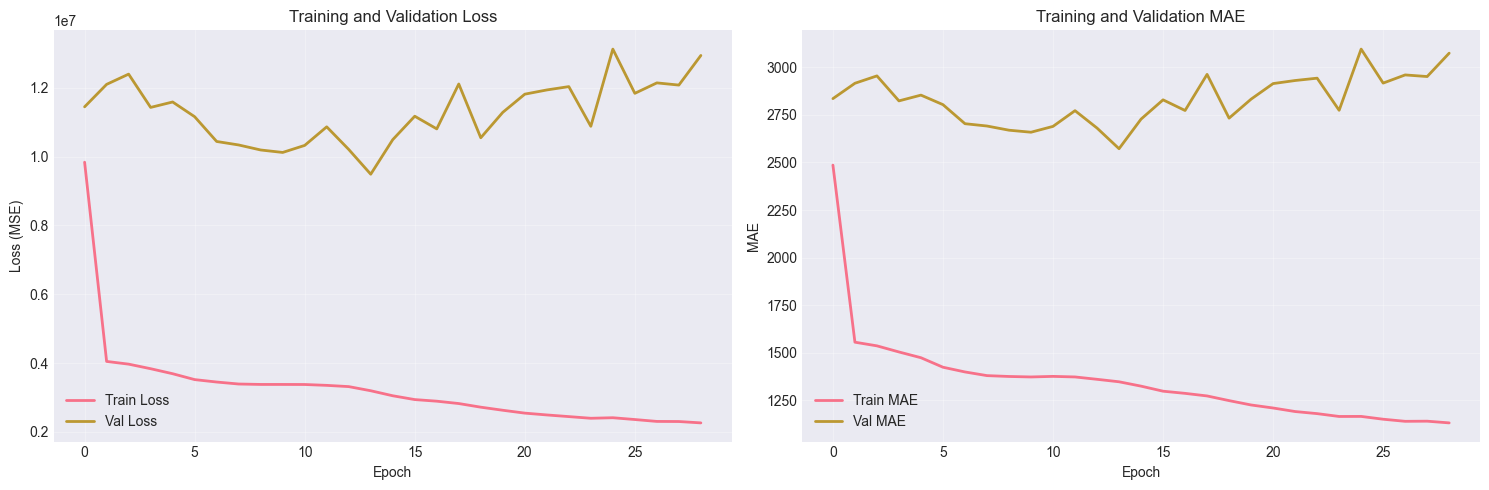


📊 Métricas finales:
   Train Loss: 2258701.93
   Val Loss: 12945251.29
   Train MAE: 1131.31
   Val MAE: 3074.52
   Best Val Loss: 9491117.70


In [18]:
# Visualizar historial de entrenamiento
print("="*80)
print("HISTORIAL DE ENTRENAMIENTO")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history['train_mae'], label='Train MAE', linewidth=2)
axes[1].plot(history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training and Validation MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas finales
print(f"\n📊 Métricas finales:")
print(f"   Train Loss: {history['train_loss'][-1]:.2f}")
print(f"   Val Loss: {history['val_loss'][-1]:.2f}")
print(f"   Train MAE: {history['train_mae'][-1]:.2f}")
print(f"   Val MAE: {history['val_mae'][-1]:.2f}")
print(f"   Best Val Loss: {best_val_loss:.2f}")

## 7. Extracción de Features (Embeddings Temporales)

Ahora que el modelo está entrenado, extraemos los **embeddings temporales** de la capa intermedia.
Estos embeddings son las nuevas features que capturan patrones temporales complejos.

In [19]:
print("="*80)
print("EXTRACCIÓN DE FEATURES (EMBEDDINGS TEMPORALES)")
print("="*80)

def extract_embeddings(model, loader, device):
    """
    Extrae embeddings temporales del modelo.
    """
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for x_temp, x_stat, _ in loader:
            x_temp, x_stat = x_temp.to(device), x_stat.to(device)
            
            # Obtener embedding (sin pasar por las capas finales)
            emb = model(x_temp, x_stat, return_embedding=True)
            embeddings.append(emb.cpu().numpy())
    
    return np.vstack(embeddings)

print(f"\n⚙️ Extrayendo embeddings...")

embeddings_train = extract_embeddings(model, train_loader, device)
embeddings_val = extract_embeddings(model, val_loader, device)
embeddings_test = extract_embeddings(model, test_loader, device)

print(f"\n✓ Embeddings extraídos:")
print(f"   Train: {embeddings_train.shape}")
print(f"   Val: {embeddings_val.shape}")
print(f"   Test: {embeddings_test.shape}")

# Mostrar ejemplo de embeddings
print(f"\n📊 Ejemplo de embedding (primera secuencia):")
print(f"   Shape: {embeddings_train[0].shape}")
print(f"   Valores: {embeddings_train[0][:10]}...")

EXTRACCIÓN DE FEATURES (EMBEDDINGS TEMPORALES)

⚙️ Extrayendo embeddings...

✓ Embeddings extraídos:
   Train: (9962, 32)
   Val: (1858, 32)
   Test: (1874, 32)

📊 Ejemplo de embedding (primera secuencia):
   Shape: (32,)
   Valores: [4.1051984 0.        3.1904898 0.        2.8662086 0.        0.2251467
 3.54338   0.3527334 3.4912357]...


## 8. Crear Dataset Aumentado con Nuevas Features

Combinamos:
1. Features originales estáticas
2. Embeddings temporales de la RNN
3. Target (rendimiento)

In [20]:
print("="*80)
print("CREACIÓN DE DATASET AUMENTADO CON RNN FEATURES")
print("="*80)

# Función para crear DataFrame con features
def create_feature_dataframe(embeddings, X_static, y, metadata, prefix='rnn_emb'):
    """
    Combina embeddings RNN, features estáticas y metadata en un DataFrame.
    """
    # Embeddings RNN
    emb_cols = [f'{prefix}_{i}' for i in range(embeddings.shape[1])]
    df_emb = pd.DataFrame(embeddings, columns=emb_cols)
    
    # Features estáticas
    df_static = pd.DataFrame(X_static, columns=static_features)
    
    # Target
    df_target = pd.DataFrame({'rendimiento': y})
    
    # Metadata
    df_meta = metadata.reset_index(drop=True)
    
    # Concatenar todo
    df_final = pd.concat([df_meta, df_static, df_emb, df_target], axis=1)
    
    return df_final

# Crear DataFrames
print("\n⚙️ Creando DataFrames con features RNN...")

df_train_rnn = create_feature_dataframe(embeddings_train, X_stat_train, y_train, metadata_train)
df_val_rnn = create_feature_dataframe(embeddings_val, X_stat_val, y_val, metadata_val)
df_test_rnn = create_feature_dataframe(embeddings_test, X_stat_test, y_test, metadata_test)

print(f"\n✓ DataFrames creados:")
print(f"   Train: {df_train_rnn.shape}")
print(f"   Val: {df_val_rnn.shape}")
print(f"   Test: {df_test_rnn.shape}")

# Mostrar primeras filas
print("\n" + "="*80)
print("PRIMERAS FILAS DEL DATASET AUMENTADO (TRAIN)")
print("="*80)
print(df_train_rnn.head())

# Información del dataset
print("\n" + "="*80)
print("INFORMACIÓN DEL DATASET")
print("="*80)
print(f"\nColumnas totales: {len(df_train_rnn.columns)}")
print(f"\nTipos de features:")
print(f"   - Metadata: {len(['año', 'departamento_nombre', 'provincia_nombre', 'cultivo'])}")
print(f"   - Features estáticas originales: {len(static_features)}")
print(f"   - Embeddings RNN (nuevas features): {EMBEDDING_DIM}")
print(f"   - Target: 1")

print(f"\nNombres de columnas:")
print(f"   {list(df_train_rnn.columns)}")

CREACIÓN DE DATASET AUMENTADO CON RNN FEATURES

⚙️ Creando DataFrames con features RNN...

✓ DataFrames creados:
   Train: (9962, 40)
   Val: (1858, 40)
   Test: (1874, 40)

PRIMERAS FILAS DEL DATASET AUMENTADO (TRAIN)
    año     departamento_nombre     provincia_nombre cultivo  suelo_ind_prod  \
0  1970               1 DE MAYO                Chaco    Maíz       19.454545   
1  1970           12 DE OCTUBRE                Chaco    Maíz       19.454545   
2  1970  ADOLFO GONZALES CHAVES         Buenos Aires    Maíz       34.550898   
3  1970                 AGUIRRE  Santiago Del Estero    Maíz       42.185393   
4  1970                ALBARDON             San Juan    Maíz       10.463415   

   suelo_porc_sue1  suelo_profund_s1  rnn_emb_0  rnn_emb_1  rnn_emb_2  ...  \
0        79.287469         61.953317   4.105198        0.0   3.190490  ...   
1        79.287469         61.953317   7.026170        0.0   5.569718  ...   
2        66.545659         77.879491   2.697189        0.0   1.976

## 9. Guardar Features y Modelos

In [21]:
print("="*80)
print("GUARDADO DE RESULTADOS")
print("="*80)

import os
import pickle

# Crear directorio si no existe
output_dir = 'data/processed/rnn_features'
os.makedirs(output_dir, exist_ok=True)

# Guardar DataFrames
print("\n💾 Guardando DataFrames con features RNN...")
df_train_rnn.to_csv(f'{output_dir}/train_rnn_features.csv', index=False)
df_val_rnn.to_csv(f'{output_dir}/val_rnn_features.csv', index=False)
df_test_rnn.to_csv(f'{output_dir}/test_rnn_features.csv', index=False)
print(f"   ✓ train_rnn_features.csv")
print(f"   ✓ val_rnn_features.csv")
print(f"   ✓ test_rnn_features.csv")

# Guardar modelo PyTorch
print("\n💾 Guardando modelo LSTM (PyTorch)...")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'best_val_loss': best_val_loss
}, f'{output_dir}/lstm_feature_extractor.pth')
print(f"   ✓ lstm_feature_extractor.pth")

# Guardar scalers
print("\n💾 Guardando scalers...")
with open(f'{output_dir}/scaler_temporal.pkl', 'wb') as f:
    pickle.dump(scaler_temporal, f)
with open(f'{output_dir}/scaler_static.pkl', 'wb') as f:
    pickle.dump(scaler_static, f)
print(f"   ✓ scaler_temporal.pkl")
print(f"   ✓ scaler_static.pkl")

# Guardar configuración
config = {
    'temporal_features': temporal_features,
    'static_features': static_features,
    'embedding_dim': EMBEDDING_DIM,
    'seq_length': 12,
    'cultivo': CULTIVO_SELECCIONADO,
    'lstm_units_1': LSTM_UNITS_1,
    'lstm_units_2': LSTM_UNITS_2,
    'dense_units': DENSE_UNITS,
    'dropout_rate': DROPOUT_RATE
}
with open(f'{output_dir}/config.pkl', 'wb') as f:
    pickle.dump(config, f)
print(f"   ✓ config.pkl")

print(f"\n✓ Todos los archivos guardados en: {output_dir}/")

GUARDADO DE RESULTADOS

💾 Guardando DataFrames con features RNN...
   ✓ train_rnn_features.csv
   ✓ val_rnn_features.csv
   ✓ test_rnn_features.csv

💾 Guardando modelo LSTM (PyTorch)...
   ✓ lstm_feature_extractor.pth

💾 Guardando scalers...
   ✓ scaler_temporal.pkl
   ✓ scaler_static.pkl
   ✓ config.pkl

✓ Todos los archivos guardados en: data/processed/rnn_features/


## 10. Análisis de las Nuevas Features

Vamos a analizar las características de los embeddings generados por la RNN.

ANÁLISIS DE EMBEDDINGS RNN

📊 Correlación de embeddings RNN con rendimiento:

Top 10 embeddings más correlacionados:
rnn_emb_22    0.005983
rnn_emb_11    0.005803
rnn_emb_0     0.005798
rnn_emb_17    0.005699
rnn_emb_7     0.005642
rnn_emb_30    0.005581
rnn_emb_19    0.005530
rnn_emb_10    0.005513
rnn_emb_14    0.005485
rnn_emb_9     0.005453


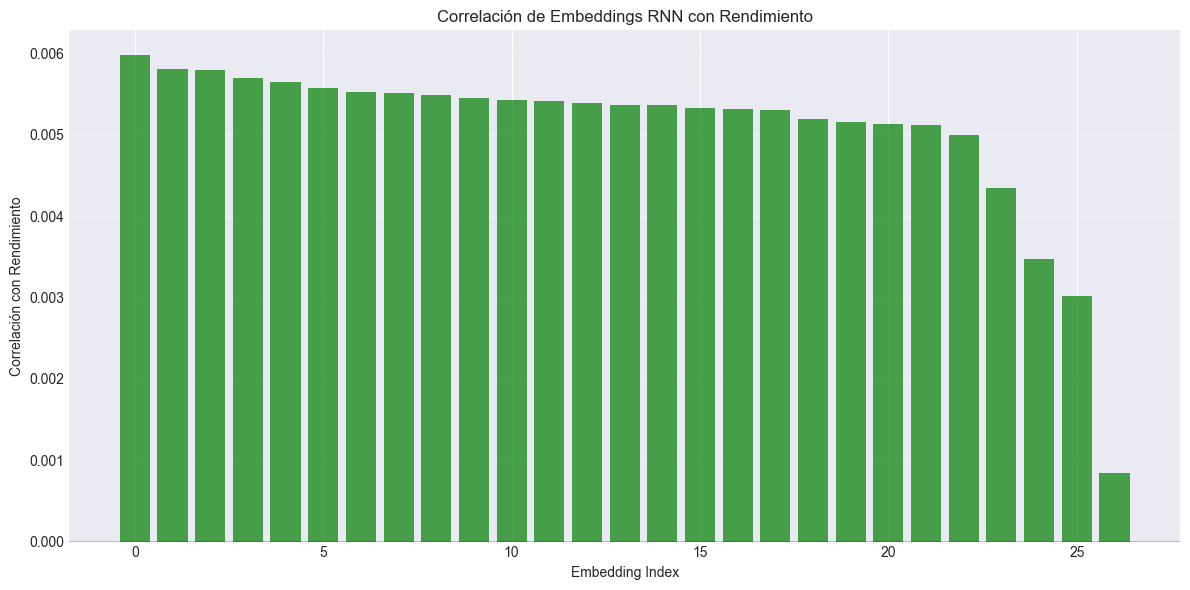

In [22]:
print("="*80)
print("ANÁLISIS DE EMBEDDINGS RNN")
print("="*80)

# Correlación de embeddings con el target
emb_cols = [col for col in df_train_rnn.columns if col.startswith('rnn_emb')]

print(f"\n📊 Correlación de embeddings RNN con rendimiento:")
correlations = df_train_rnn[emb_cols + ['rendimiento']].corr()['rendimiento'].drop('rendimiento').sort_values(ascending=False)

print(f"\nTop 10 embeddings más correlacionados:")
print(correlations.head(10).to_string())

# Visualización
plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
plt.bar(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
plt.xlabel('Embedding Index')
plt.ylabel('Correlación con Rendimiento')
plt.title('Correlación de Embeddings RNN con Rendimiento')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

DISTRIBUCIÓN DE EMBEDDINGS


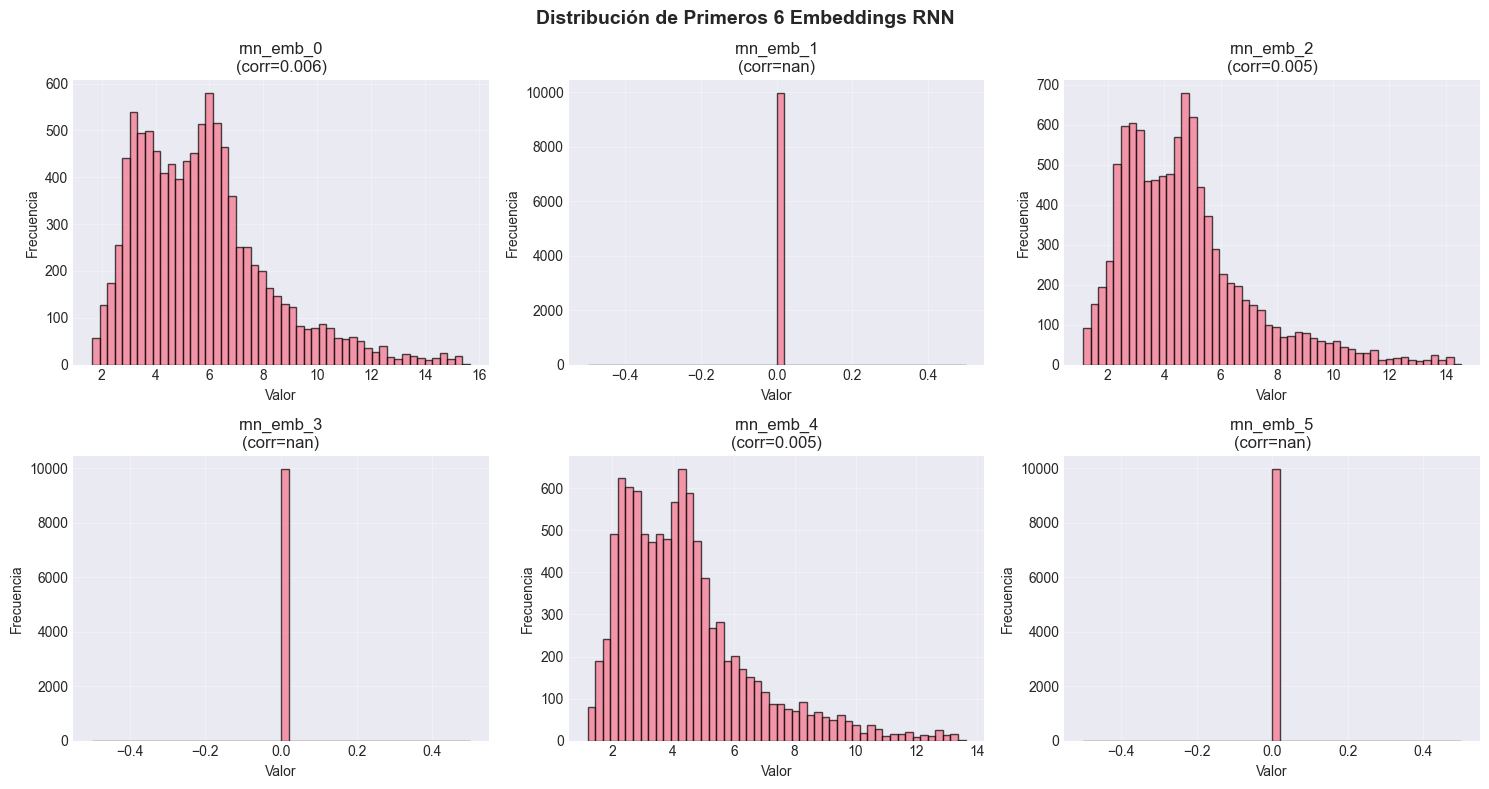

In [23]:
# Distribución de embeddings
print("="*80)
print("DISTRIBUCIÓN DE EMBEDDINGS")
print("="*80)

# Seleccionar algunos embeddings para visualizar
emb_to_plot = emb_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, emb_col in enumerate(emb_to_plot):
    axes[idx].hist(df_train_rnn[emb_col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{emb_col}\n(corr={correlations[emb_col]:.3f})')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(alpha=0.3)

plt.suptitle('Distribución de Primeros 6 Embeddings RNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

VISUALIZACIÓN PCA DE EMBEDDINGS

Varianza explicada por componentes PCA:
   PC1: 99.64%
   PC2: 0.29%
   Total: 99.92%


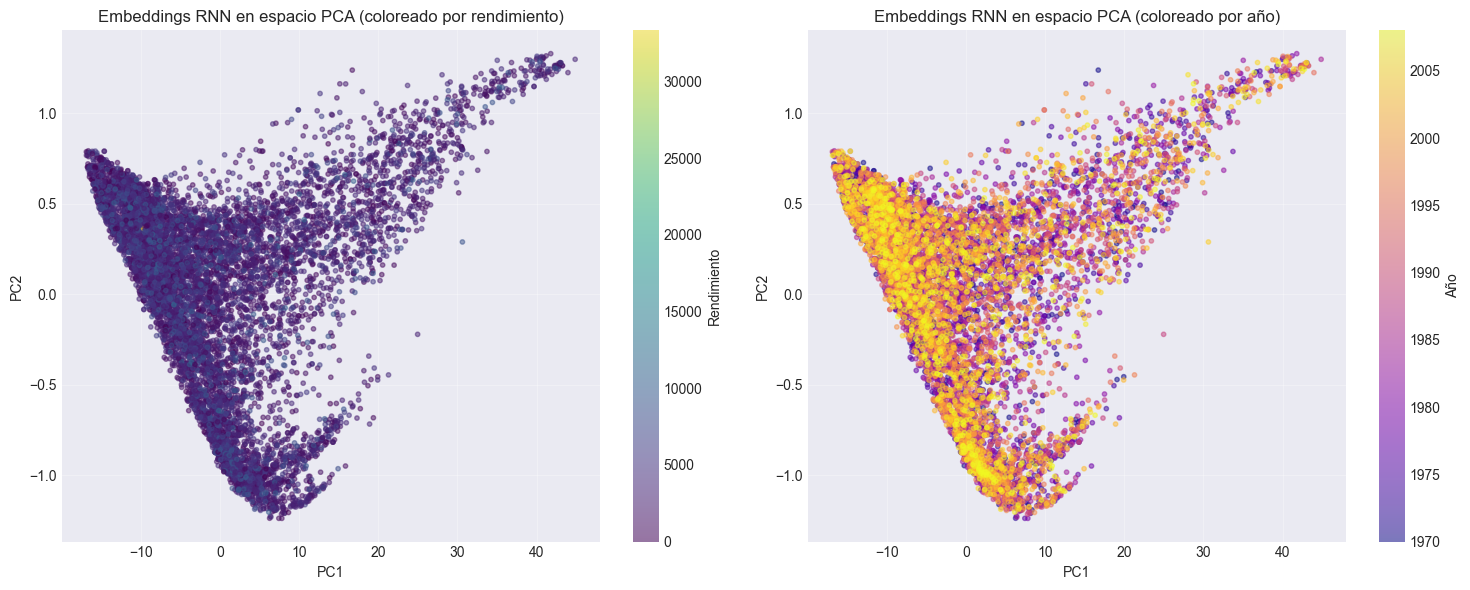

In [24]:
# Visualización PCA de embeddings
print("="*80)
print("VISUALIZACIÓN PCA DE EMBEDDINGS")
print("="*80)

from sklearn.decomposition import PCA

# Aplicar PCA para visualizar en 2D
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings_train)

print(f"\nVarianza explicada por componentes PCA:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter coloreado por rendimiento
scatter = axes[0].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], 
                         c=y_train, cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Embeddings RNN en espacio PCA (coloreado por rendimiento)')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Rendimiento')

# Scatter coloreado por año
scatter2 = axes[1].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], 
                          c=metadata_train['año'], cmap='plasma', alpha=0.5, s=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Embeddings RNN en espacio PCA (coloreado por año)')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Año')

plt.tight_layout()
plt.show()

## 11. Uso de Features RNN en Modelos Downstream

Ahora podemos usar estas features en cualquier modelo de ML tradicional.

In [25]:
print("="*80)
print("EJEMPLO: MODELO DOWNSTREAM CON FEATURES RNN")
print("="*80)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Preparar features
# Opción 1: Solo embeddings RNN
X_train_emb = df_train_rnn[emb_cols].values
X_val_emb = df_val_rnn[emb_cols].values
X_test_emb = df_test_rnn[emb_cols].values

# Opción 2: Embeddings + features estáticas
feature_cols = emb_cols + static_features
X_train_all = df_train_rnn[feature_cols].values
X_val_all = df_val_rnn[feature_cols].values
X_test_all = df_test_rnn[feature_cols].values

print(f"\n⚙️ Features para modelo downstream:")
print(f"   Solo embeddings RNN: {X_train_emb.shape}")
print(f"   Embeddings + estáticas: {X_train_all.shape}")

# Entrenar Random Forest con ambas opciones
print(f"\n🌲 Entrenando Random Forest...")

# Modelo 1: Solo embeddings
rf_emb = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_emb.fit(X_train_emb, y_train)
pred_emb = rf_emb.predict(X_test_emb)
r2_emb = r2_score(y_test, pred_emb)
rmse_emb = np.sqrt(mean_squared_error(y_test, pred_emb))
mae_emb = mean_absolute_error(y_test, pred_emb)

# Modelo 2: Embeddings + estáticas
rf_all = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_all.fit(X_train_all, y_train)
pred_all = rf_all.predict(X_test_all)
r2_all = r2_score(y_test, pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test, pred_all))
mae_all = mean_absolute_error(y_test, pred_all)

# Resultados
print(f"\n" + "="*80)
print("RESULTADOS - RANDOM FOREST")
print("="*80)

print(f"\n📊 Modelo 1: Solo Embeddings RNN")
print(f"   R² Score: {r2_emb:.4f}")
print(f"   RMSE: {rmse_emb:.2f}")
print(f"   MAE: {mae_emb:.2f}")

print(f"\n📊 Modelo 2: Embeddings RNN + Features Estáticas")
print(f"   R² Score: {r2_all:.4f}")
print(f"   RMSE: {rmse_all:.2f}")
print(f"   MAE: {mae_all:.2f}")

# Comparación
mejora = ((r2_all - r2_emb) / abs(r2_emb)) * 100 if r2_emb != 0 else 0
print(f"\n💡 Mejora al agregar features estáticas: {mejora:+.2f}% en R²")

EJEMPLO: MODELO DOWNSTREAM CON FEATURES RNN

⚙️ Features para modelo downstream:
   Solo embeddings RNN: (9962, 32)
   Embeddings + estáticas: (9962, 35)

🌲 Entrenando Random Forest...

RESULTADOS - RANDOM FOREST

📊 Modelo 1: Solo Embeddings RNN
   R² Score: -2.3200
   RMSE: 3738.66
   MAE: 3286.57

📊 Modelo 2: Embeddings RNN + Features Estáticas
   R² Score: -1.9469
   RMSE: 3522.32
   MAE: 3141.05

💡 Mejora al agregar features estáticas: +16.08% en R²


IMPORTANCIA DE FEATURES - RANDOM FOREST

Top 15 features más importantes:
         Feature  Importance
  suelo_ind_prod    0.510108
 suelo_porc_sue1    0.083046
      rnn_emb_21    0.077503
suelo_profund_s1    0.070561
       rnn_emb_8    0.043182
       rnn_emb_6    0.039870
      rnn_emb_26    0.017403
      rnn_emb_27    0.012120
       rnn_emb_4    0.010781
      rnn_emb_22    0.010145
      rnn_emb_24    0.009110
      rnn_emb_11    0.009020
       rnn_emb_9    0.007935
      rnn_emb_13    0.007529
      rnn_emb_16    0.007417


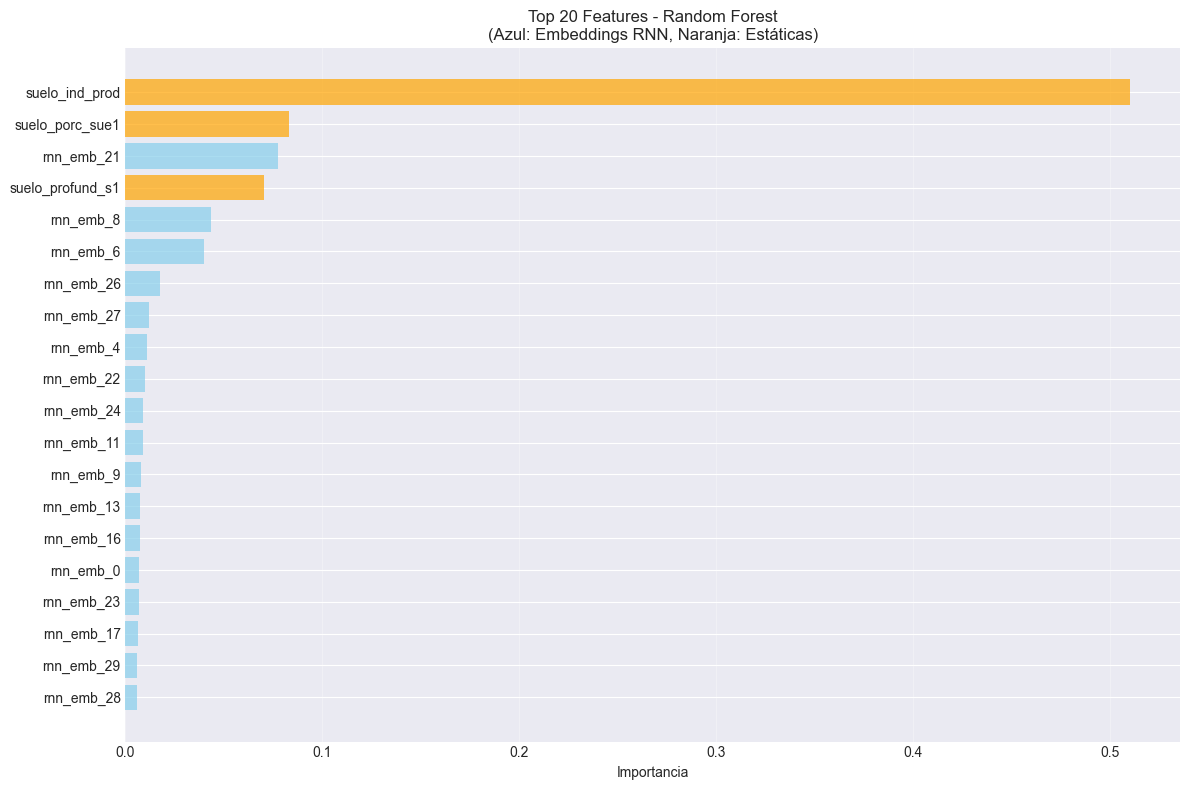


📊 Importancia total por tipo de feature:
   Embeddings RNN: 0.3363 (33.6%)
   Features estáticas: 0.6637 (66.4%)


In [26]:
# Feature importance del Random Forest
print("="*80)
print("IMPORTANCIA DE FEATURES - RANDOM FOREST")
print("="*80)

# Obtener importancias
importances = rf_all.feature_importances_
feature_names = feature_cols

# Crear DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\nTop 15 features más importantes:")
print(importance_df.head(15).to_string(index=False))

# Visualización
plt.figure(figsize=(12, 8))
top_n = 20
top_features = importance_df.head(top_n)

# Colorear diferentes tipos de features
colors = ['skyblue' if 'rnn_emb' in f else 'orange' for f in top_features['Feature']]

plt.barh(range(len(top_features)), top_features['Importance'].values, color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importancia')
plt.title(f'Top {top_n} Features - Random Forest\n(Azul: Embeddings RNN, Naranja: Estáticas)')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas
rnn_importance = importance_df[importance_df['Feature'].str.startswith('rnn_emb')]['Importance'].sum()
static_importance = importance_df[~importance_df['Feature'].str.startswith('rnn_emb')]['Importance'].sum()

print(f"\n📊 Importancia total por tipo de feature:")
print(f"   Embeddings RNN: {rnn_importance:.4f} ({rnn_importance/(rnn_importance+static_importance)*100:.1f}%)")
print(f"   Features estáticas: {static_importance:.4f} ({static_importance/(rnn_importance+static_importance)*100:.1f}%)")

## 12. Resumen y Próximos Pasos

In [27]:
print("="*80)
print("RESUMEN FINAL - RNN FEATURE ENGINEERING CON PYTORCH")
print("="*80)

print(f"""
✅ PROCESO COMPLETADO EXITOSAMENTE

📊 DATOS:
   • Cultivo: {CULTIVO_SELECCIONADO}
   • Total secuencias: {len(y):,}
   • Train/Val/Test: {len(y_train):,} / {len(y_val):,} / {len(y_test):,}
   • Período: {metadata['año'].min()} - {metadata['año'].max()}

🧠 MODELO RNN (PYTORCH):
   • Arquitectura: LSTM Encoder
   • Input temporal: {len(temporal_features)} features x 12 meses
   • Input estático: {len(static_features)} features
   • Embeddings generados: {EMBEDDING_DIM} dimensiones
   • LSTM units: {LSTM_UNITS_1} → {LSTM_UNITS_2}
   • Parámetros totales: {total_params:,}
   • Device: {device}

📈 RESULTADOS:
   • Best Val Loss (MSE): {best_val_loss:.2f}
   • Train Loss (MSE): {history['train_loss'][-1]:.2f}
   • Val Loss (MSE): {history['val_loss'][-1]:.2f}
   • RF con embeddings - R²: {r2_emb:.4f}
   • RF con embeddings+estáticas - R²: {r2_all:.4f}

💾 ARCHIVOS GENERADOS:
   • {output_dir}/train_rnn_features.csv
   • {output_dir}/val_rnn_features.csv
   • {output_dir}/test_rnn_features.csv
   • {output_dir}/lstm_feature_extractor.pth (PyTorch checkpoint)
   • {output_dir}/scaler_temporal.pkl
   • {output_dir}/scaler_static.pkl
   • {output_dir}/config.pkl

🎯 PRÓXIMOS PASOS:
   1. Probar con otros cultivos
   2. Experimentar con arquitecturas diferentes (GRU, Bidirectional LSTM)
   3. Ajustar hiperparámetros (embedding_dim, lstm_units, dropout)
   4. Agregar más features temporales (índices de vegetación, etc.)
   5. Probar modelos downstream más avanzados (XGBoost, LightGBM)
   6. Implementar attention mechanisms
   7. Crear ensembles con múltiples arquitecturas
   8. Experimentar con Transformers para series temporales

💡 USO DE LAS FEATURES:
   Los archivos CSV generados contienen {EMBEDDING_DIM} nuevas features (rnn_emb_0 a rnn_emb_{EMBEDDING_DIM-1})
   que capturan patrones temporales complejos en los datos climáticos mensuales.
   
   Puedes usarlas directamente en cualquier modelo de ML:
   - df = pd.read_csv('{output_dir}/train_rnn_features.csv')
   - features = [col for col in df.columns if col.startswith('rnn_emb')]
   - X = df[features].values
   - y = df['rendimiento'].values

🔄 CÓMO CARGAR EL MODELO ENTRENADO:
   checkpoint = torch.load('{output_dir}/lstm_feature_extractor.pth')
   model.load_state_dict(checkpoint['model_state_dict'])
   model.eval()

""")

print("="*80)
print("FEATURE ENGINEERING CON RNN (PYTORCH) COMPLETADO ✅")
print("="*80)

RESUMEN FINAL - RNN FEATURE ENGINEERING CON PYTORCH

✅ PROCESO COMPLETADO EXITOSAMENTE

📊 DATOS:
   • Cultivo: Maíz
   • Total secuencias: 13,694
   • Train/Val/Test: 9,962 / 1,858 / 1,874
   • Período: 1970 - 2024

🧠 MODELO RNN (PYTORCH):
   • Arquitectura: LSTM Encoder
   • Input temporal: 2 features x 12 meses
   • Input estático: 3 features
   • Embeddings generados: 32 dimensiones
   • LSTM units: 128 → 64
   • Parámetros totales: 124,641
   • Device: cpu

📈 RESULTADOS:
   • Best Val Loss (MSE): 9491117.70
   • Train Loss (MSE): 2258701.93
   • Val Loss (MSE): 12945251.29
   • RF con embeddings - R²: -2.3200
   • RF con embeddings+estáticas - R²: -1.9469

💾 ARCHIVOS GENERADOS:
   • data/processed/rnn_features/train_rnn_features.csv
   • data/processed/rnn_features/val_rnn_features.csv
   • data/processed/rnn_features/test_rnn_features.csv
   • data/processed/rnn_features/lstm_feature_extractor.pth (PyTorch checkpoint)
   • data/processed/rnn_features/scaler_temporal.pkl
   • data/